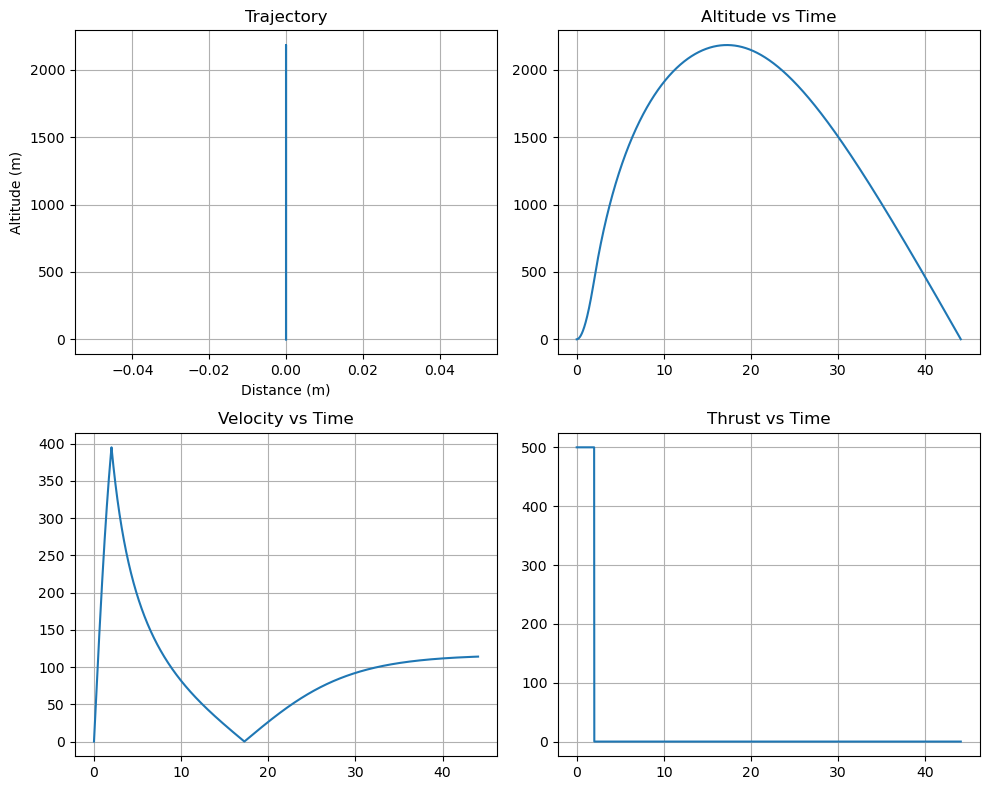

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# constants
g = 9.81
rho = 1.225
Cd = 0.3

diameter = 0.1
A = np.pi*(diameter/2)**2

mass = 2
Tmax = 500
burn_time = 2

dt = 0.01
t_max = 60

# initial conditions
x=0
y=0
vx=0
vy=0

x_list=[]
y_list=[]
v_list=[]
t_list=[]
thrust_list=[]

for t in np.arange(0,t_max,dt):

    # thrust
    if t<=burn_time:
        T=Tmax
    else:
        T=0

    # velocity magnitude
    v=np.sqrt(vx**2+vy**2)

    # drag
    D=0.5*rho*Cd*A*v**2

    if v>0:
        Dx=D*(vx/v)
        Dy=D*(vy/v)
    else:
        Dx=0
        Dy=0

    # acceleration
    ax=(-Dx)/mass
    ay=(T-Dy)/mass-g

    # update velocity
    vx=vx+ax*dt
    vy=vy+ay*dt

    # update position
    x=x+vx*dt
    y=y+vy*dt

    # stop when rocket hits ground AFTER launch
    if y<0 and t>1:
        break

    x_list.append(x)
    y_list.append(y)
    v_list.append(v)
    t_list.append(t)
    thrust_list.append(T)

# ---------------- PLOTS ----------------

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(x_list,y_list)
plt.title("Trajectory")
plt.xlabel("Distance (m)")
plt.ylabel("Altitude (m)")
plt.grid()

plt.subplot(2,2,2)
plt.plot(t_list,y_list)
plt.title("Altitude vs Time")
plt.grid()

plt.subplot(2,2,3)
plt.plot(t_list,v_list)
plt.title("Velocity vs Time")
plt.grid()

plt.subplot(2,2,4)
plt.plot(t_list,thrust_list)
plt.title("Thrust vs Time")
plt.grid()

plt.tight_layout()
plt.show()